<a href="https://colab.research.google.com/github/2005akshaya/AI_NarrativeNexus/blob/main/Sentimental_Analyzing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%writefile reddit.py
import streamlit as st
import json
import praw
import pandas as pd
import uuid
from datetime import datetime, timezone
import os

# ----------------------------
# ✅ Reddit API authentication
# ----------------------------
def init_reddit():
    return praw.Reddit(
        client_id="iG9C35PhDmFPaObXbS2cvcRhnETVUA",
        client_secret="tt78RM7C0r9aknY1ocVVMA",
        user_agent="RedditTextExtractor by u/EastSlide9495"
    )

# ----------------------------
# ✅ Extract text data from a Reddit URL
# ----------------------------
def fetch_post_data(url):
    reddit = init_reddit()
    submission = reddit.submission(url=url)

    post_data = {
        "id": str(uuid.uuid4()),
        "source": "reddit",
        "author": str(submission.author) if submission.author else "unknown",
        "timestamp": datetime.fromtimestamp(
            submission.created_utc, tz=timezone.utc
        ).isoformat(),
        "text": submission.selftext if submission.selftext else submission.title,
        "metadata": {
            "language": "en",
            "likes": submission.score,
            "rating": None,
            "url": url,
        },
    }
    return post_data

# ----------------------------
# ✅ Save data to JSON/CSV
# ----------------------------
def save_data(data, format="json", filename="output_data"):
    os.makedirs("data", exist_ok=True)
    filepath = os.path.join("data", f"{filename}.{format}")

    if format == "json":
        pd.DataFrame([data]).to_json(filepath, orient="records", indent=4)
    elif format == "csv":
        pd.DataFrame([data]).to_csv(filepath, index=False, encoding="utf-8")

    return filepath

# ----------------------------
# ✅ Streamlit UI
# ----------------------------
st.set_page_config(page_title="Reddit Text Extractor", layout="wide")
st.title("📥 Reddit Text Data Extractor")

url = st.text_input("Enter Reddit link:")
format_option = st.selectbox("Save as:", ["JSON", "CSV"])

if st.button("Fetch & Save"):
    if url:
        with st.spinner("Fetching data..."):
            data = fetch_post_data(url)
            file_path = save_data(data, format=format_option.lower())

        st.success(f"✅ Data saved to {file_path}")

        st.subheader("Preview")
        st.json(data)
    else:
        st.error("Please enter a valid Reddit URL")

Writing reddit.py


In [2]:
!pip install transformers
!pip install seaborn


In [ ]:
train_path = "/content/amazon_reviews_train.csv"
test_path  = "/content/amazon_reviews_test.csv"



import re
import nltk
import pandas as pd
nltk.download("stopwords")
nltk.download("wordnet")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """Basic cleaning: lowercasing, removing special chars, stopwords, lemmatization"""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return " ".join(tokens)


train_df = pd.read_csv(train_path, nrows=50000, on_bad_lines='skip')
test_df  = pd.read_csv(test_path, nrows=10000, on_bad_lines='skip')


train_df["text"] = (train_df["title"].astype(str) + " " + train_df["content"].astype(str)).apply(clean_text)
test_df["text"]  = (test_df["title"].astype(str) + " " + test_df["content"].astype(str)).apply(clean_text)

X_train, y_train = train_df["text"], train_df["label"]
X_test,  y_test  = test_df["text"],  test_df["label"]

print("Train size:", len(X_train), " Test size:", len(X_test))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Train size: 50000  Test size: 10000


 Random Forest Results:
Accuracy: 0.8513
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      4875
           1       0.85      0.86      0.86      5125

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



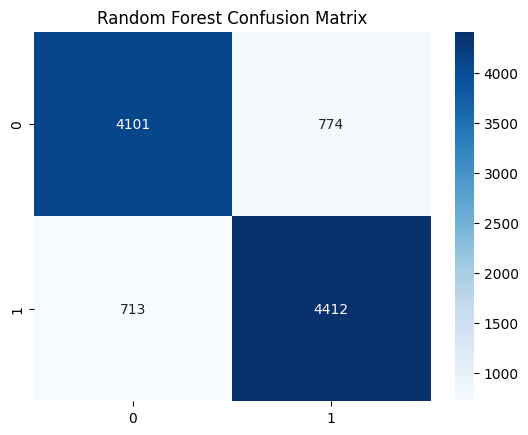

In [ ]:

# MODEL 1: Random Forest

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Vectorize
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

# Train
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)

# Evaluation
print(" Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [ ]:
import joblib

# Save in Colab
joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

# Download to local machine
from google.colab import files
files.download("random_forest_model.pkl")
files.download("tfidf_vectorizer.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 245s 601ms/step - accuracy: 0.7592 - loss: 0.4745 - val_accuracy: 0.8767 - val_loss: 0.2936
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 238s 610ms/step - accuracy: 0.9133 - loss: 0.2307 - val_accuracy: 0.8757 - val_loss: 0.3005
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 238s 609ms/step - accuracy: 0.9347 - loss: 0.1773 - val_accuracy: 0.8705 - val_loss: 0.3360
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step
 LSTM Results:
Accuracy: 0.8705
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      4875
           1       0.86      0.89      0.88      5125

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



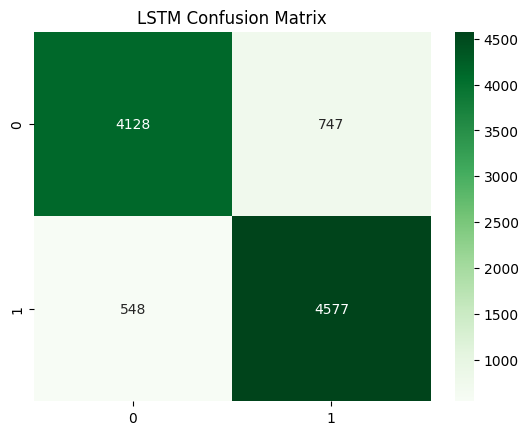

In [ ]:
# MODEL 2: LSTM
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Tokenization
tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=200)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=200)

# Build model
model_lstm = Sequential([
    Embedding(input_dim=20000, output_dim=128, input_length=200),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_lstm.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

# Train (use smaller epochs first!)
history = model_lstm.fit(
    X_train_seq, np.array(y_train),
    epochs=3, batch_size=128,
    validation_data=(X_test_seq, np.array(y_test))
)

# Evaluate
y_pred_lstm = (model_lstm.predict(X_test_seq) > 0.5).astype("int32").flatten()
print(" LSTM Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lstm))
print(classification_report(y_test, y_pred_lstm))

cm = confusion_matrix(y_test, y_pred_lstm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("LSTM Confusion Matrix")
plt.show()


In [ ]:
# Save in Colab
model_lstm.save("lstm_model.h5")
joblib.dump(tokenizer, "lstm_tokenizer.pkl")

# Download to local machine
from google.colab import files
files.download("lstm_model.h5")
files.download("lstm_tokenizer.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Collect metrics
results = {
    "Model": ["Random Forest", "LSTM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lstm),

    ],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_lstm),

    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_lstm),

    ],
    "F1-Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_lstm),

    ],
}

df_results = pd.DataFrame(results)
print(" Model Performance Summary")
display(df_results)


 Model Performance Summary


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.8513,0.850752,0.860878,0.855785
1,LSTM,0.8705,0.859692,0.893073,0.876065


In [ ]:
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences



In [ ]:
# Load saved RF + TF-IDF
rf_loaded = joblib.load("random_forest_model.pkl")
vectorizer_loaded = joblib.load("tfidf_vectorizer.pkl")

def predict_rf(text):
    text_clean = clean_text(text)
    vec = vectorizer_loaded.transform([text_clean])
    pred = rf_loaded.predict(vec)[0]
    return "Positive " if pred == 1 else "Negative "


In [ ]:

lstm_loaded = load_model("lstm_model.h5")
tokenizer_loaded = joblib.load("lstm_tokenizer.pkl")

def predict_lstm(text):
    text_clean = clean_text(text)
    seq = tokenizer_loaded.texts_to_sequences([text_clean])
    padded = pad_sequences(seq, maxlen=200)
    pred = (lstm_loaded.predict(padded) > 0.5).astype("int32")[0][0]
    return "Positive " if pred == 1 else "Negative "


In [ ]:
sample_texts = [
    "This product is absolutely fantastic, I loved it!",
    "Worst purchase ever, total waste of money.",
    "It was okay, nothing special but not bad either."
]

for txt in sample_texts:
    print(f"\nINPUT: {txt}")
    print("Random Forest →", predict_rf(txt))
    print("LSTM          →", predict_lstm(txt))




INPUT: This product is absolutely fantastic, I loved it!
Random Forest → Positive 
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step
LSTM          → Positive 

INPUT: Worst purchase ever, total waste of money.
Random Forest → Negative 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
LSTM          → Negative 

INPUT: It was okay, nothing special but not bad either.
Random Forest → Negative 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
LSTM          → Negative 


In [ ]:
# Install VADER if not already installed
!pip install vaderSentiment
import nltk
nltk.download("punkt")
nltk.download('punkt_tab') # Add this line to download the missing resource


from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import classification_report, accuracy_score

# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# Function to compute sentence-level sentiment
def get_sentiment_sentence_level(text):
    from nltk.tokenize import sent_tokenize
    sentences = sent_tokenize(text)  # split into sentences
    if not sentences:
        return 1  # default to positive if empty

    # Compute compound score for each sentence
    scores = [analyzer.polarity_scores(sent)["compound"] for sent in sentences]
    avg_score = sum(scores)/len(scores)

    # Convert average compound score to binary label
    return 1 if avg_score >= 0 else 0

# Apply sentence-level sentiment to preprocessed text
train_df["pred_label"] = train_df["text"].apply(get_sentiment_sentence_level)
test_df["pred_label"]  = test_df["text"].apply(get_sentiment_sentence_level)

# Evaluate
print("Train Accuracy:", accuracy_score(train_df["label"], train_df["pred_label"]))
print("Test Accuracy:", accuracy_score(test_df["label"], test_df["pred_label"]))

print("\nTest Classification Report:\n")
print(classification_report(test_df["label"], test_df["pred_label"]))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Train Accuracy: 0.67954
Test Accuracy: 0.68

Test Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.41      0.56      4875
           1       0.63      0.93      0.75      5125

    accuracy                           0.68     10000
   macro avg       0.74      0.67      0.65     10000
weighted avg       0.74      0.68      0.66     10000

